## 第一章：概述

> ## pip install xxx
> ## pip uninstall xxx
> ## pip freeze
> ## pip install --upgrade xxx

> ## import 模块名
>> ## from xxx import xxx (as xxx)

> ## __name__属性的理解

In [1]:
import hello
hello.main()
hello.__name__, __name__

This programme is used as a modual


('hello', '__main__')

In [2]:
def main():
    if __name__=='__main__':        
        print('This programme is run directly')
    elif __name__=='hello':
        print('This programme is used as a modual')
        
main()
__name__

This programme is run directly


'__main__'

## 第二章：运算符、表达式与内置对象

> ## python内置对象：列表，元组，字典，集合，字符串 (表2-2几种对象的特点)

> ## Python运算符与表达式：//，%，**，< > ==...,| ^ & <<  >>..., in is,

> ## Python关键字

> ## Python内置函数用法（min, max, sum, divmod, next, range, sorted, reversed, zip, map,enumertate, filter,reduce）

In [16]:
3<<2

12

In [18]:
x = [1,2,3]
list(filter(lambda x:x>2,x))

[3]

In [4]:
from functools import reduce
a = [1,2,3,4]
reduce(lambda x,y:x-y,a)

-8

In [77]:
from functools import reduce
def main(lst1, lst2):
    zipped = zip(lst1, lst2)
    summed = reduce(lambda x,y :x+y, zipped)
    return summed

list1 = [1, 2, 3]
list2 = [4, 5, 6]
output = main(list1, list2)
print(output) 

(1, 4, 2, 5, 3, 6)


In [21]:
eval('3'+'5')

35

In [1]:
5.2%4

1.2000000000000002

In [7]:
x = input('please input a number:')
eval(x)+4

please input a number:5


9

In [27]:
x = [1,2,3]
y= reversed(x)
next(y), x

(3, [1, 2, 3])

In [28]:
print(*y)

2 1


In [99]:
#5.完成填空，要求：遍历所有位置参数，遇到None时停止打印。
def print_until_none(*args):
    for idx, val in enumerate(args):
        if val is None:
            break             
        print(idx, val)  
            
print_until_none('a', 'b', None, 'c')

0 a
1 b


In [110]:
#6.完成填空，要求：遍历0~9的数，跳过能被3整除的数，其他数平方后组成列表。
def square_non_multiples_of_three():
    result = []
    for i in range(10):
        if i % 3 == 0:
            continue
        result.append(i*i) 
    return result

print(square_non_multiples_of_three())

[1, 4, 16, 25, 49, 64]


## 第三章 Python 可迭代对象

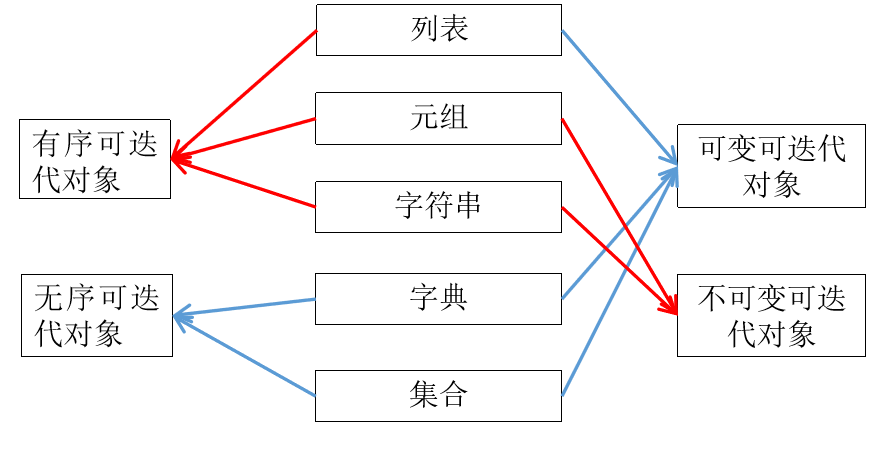

> ## 迭代器对象（zip, map,enumertate, filter，生成器对象）不支持下标和切片运算和访问，也不支持内置函数len()

>## range对象不支持切片运算和下标，也不支持方法__next__()

> ## 列表操作：remove，pop，index，reverse（reversed）， sort（sorted）， append，insert，extend，

> ## =,copy,deepcopy

> ## 重点：列表推导式

> ## 列表切片操作：切片得到的是列表的浅复制

In [22]:
x = [1,2,3]
y = x
y[2] = 5
x

[1, 2, 5]

In [8]:
x = [1,2,3,[4,5]]
y = x.copy()
y[2] = 5
x

[1, 2, 3, [4, 5]]

In [9]:
y[3][0]=9
x

[1, 2, 3, [9, 5]]

In [30]:
import copy
x = [1,2,3,[4,5]]
y = copy.deepcopy(x)
y[3][0]=9
x

[1, 2, 3, [4, 5]]

In [31]:
vec = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
x=[number for element in vec for number in element]
x

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [52]:
#1.完成填空，要求函数main()接收一个包含若干整数的列表lst，要求返回一个列表，列表中包含原列表中大于所有整数平均数的整数。
def main(lst):
    return [i for i in lst if i>sum(lst)/len(lst)]

main([0,1,2,3])

[2, 3]

In [38]:
def main(lst):
    return list(filter(lambda x:x>sum(lst)/len(lst),lst))

main([0,1,2,3])

[2, 3]

In [69]:
##3.完成填空，要求：计算一个列表中所有偶数元素的累加和.
from functools import reduce
def sum_even(lst):
    even_numbers = [x for x in lst if x % 2 == 0]
    return reduce(lambda x, y: x + y, even_numbers)

print(sum_even([1, 2, 3, 4, 5, 6]))

12


In [73]:
#4.完成填空，要求：利用zip实现把两个列表的元素按索引对应相加，生成新列表。
def add_pairs(a,b):
    return [x + y for x, y in zip(a, b)] #[sum([x,y]) for x, y in zip(a, b)] or [sum(i) for i in zip(a, b)]

print(add_pairs([1, 2, 3], [4, 5, 6]))

[5, 7, 9]


In [32]:
aList = [3, 5, 7, ['a','b']]
bList = aList[1::2] 
bList[1].append(8)
bList, aList

([5, ['a', 'b', 8]], [3, 5, 7, ['a', 'b', 8]])

In [116]:
#8. 完成填空，要求实现一个函数，返回输入列表去掉第一个元素后的新列表。
def remove_first(lst):
    return lst[1:]

print(remove_first([1,2,3]))

[2, 3]


In [117]:
def remove_first(lst):
    return [y for i,y in enumerate(lst) if i>0 ]

print(remove_first([1,2,3]))

[2, 3]


In [128]:
# 9.完成填空，要求生成一个包含20个随机整数的列表，然后对其中偶数下标的元素进行降序排列，奇数下标的元素不变。
import random  
def main():
    x = [random.randint(0,100) for i in range(20)]
    x[::2] = sorted(x[::2], reverse=True) #注意sort和sorted区别
    return x

main()

[99, 3, 97, 34, 78, 37, 78, 6, 76, 96, 69, 50, 44, 77, 34, 76, 25, 81, 1, 19]

> ## 元组：不可变序列：不可以直接修改元组中的元素，也无法为元组增加或者删除元素

> ## 元组可以作为字典的键，但是列表不可以

> ## 重点：生成器推导式 !

> 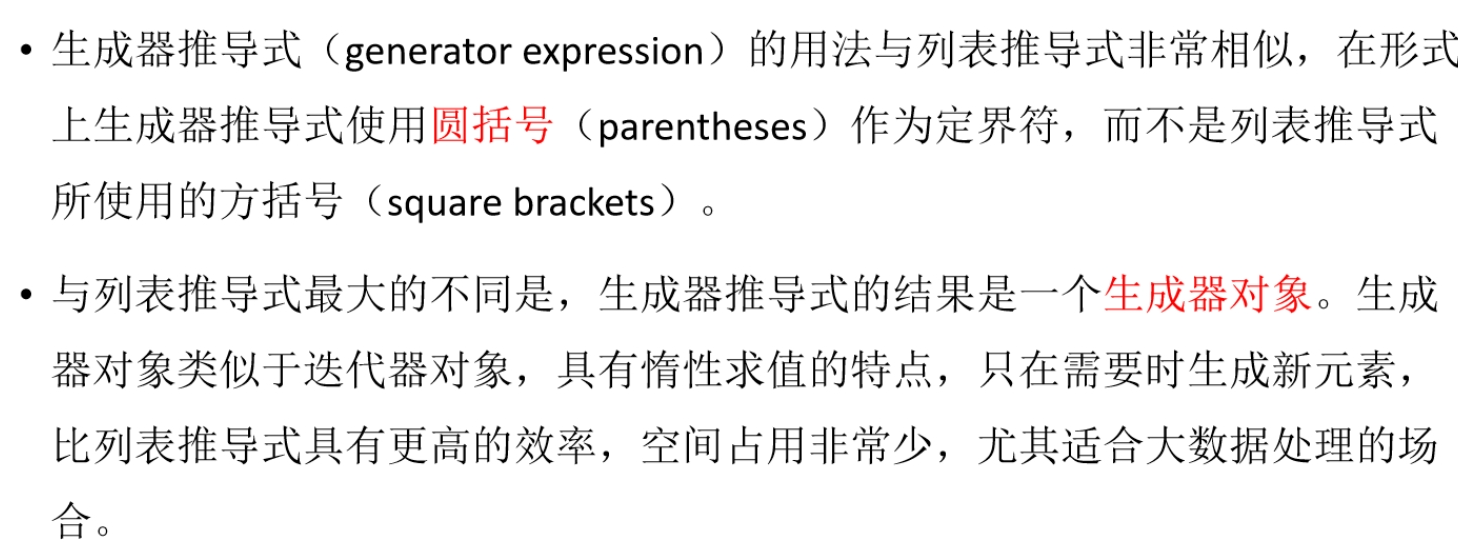

> ## 惰性求值的特点

In [29]:
{(1,2,3):4}

{(1, 2, 3): 4}

In [30]:
{[1,2,3]:4}

TypeError: unhashable type: 'list'

In [38]:
#hash([1,2,3])
hash(1)

1

In [10]:
g = ((i+2)**2 for i in range(10))
g

<generator object <genexpr> at 0x000002C4B768D580>

In [11]:
next(g),g.__next__()

(4, 9)

In [80]:
#2.完成填空，要求：实现一个函数，返回一个生成器对象，该生成器对象能依次产生0到n-1的偶数。
def even_gen(n):
    return (i for i in range(n) if i % 2 == 0)# or (i for i in range(0,n,2))

for num in even_gen(5):
    print(num)

0
2
4


In [86]:
def even_gen(n):
    yield from [i for i in range(n) if i % 2 == 0]# or (i for i in range(0,n,2))

for num in even_gen(5):
    print(num)

0
2
4


> ## 字典：无序可变序列（通过“键”添加，update(),pop(),popitem()），“键”不允许重复

> ## 字典： 对字典对象直接进行迭代或者遍历时默认是遍历字典的“键”

> ## 字典创建的方式 help(dict) #第三章 第三次课

> ## 字典的键keys()，值values()，键、值对 items()

> ## 字典的元素访问：键，get()方法

In [49]:
aDict = {'age': 39, 'score': [98, 97], 'name': 'Dong', 'sex': 'male'}
aDict['sex'] 

'male'

In [44]:
aDict.get('age', 'Not Exists.') #指定的“键”不存在时返回指定的默认值

39

> ## 集合：无序可变序列(add(),update(),pop(),discard(),remove())，里面元素不可以重复且必须是可哈希的

In [51]:
{1,2,[1,2]}

TypeError: unhashable type: 'list'

In [115]:
#7、完成填空，要求接收一个包含若干整数的列表lst，要求返回一个新列表，
#新列表lst2包含lst中的唯一元素（重复元素只保留一个），并且里面的元素按从大到小的顺序排列。
def main(lst):
    lst2 = sorted(set(lst),reverse=True) 
    return lst2
main([1,3,2,1,4])

[4, 3, 2, 1]

> ## 序列解包 * **

In [16]:
x = [3,2,1]
x.sort()
#x

In [18]:
x = [3,2,1]
sorted(x),x

([1, 2, 3], [3, 2, 1])

## 第四章 程序控制结构

> ## 程序控制结构： 条件表达式，选择结构（ 单分支if，双分支 if...else...），循环结构

> ## break 与 continue

> 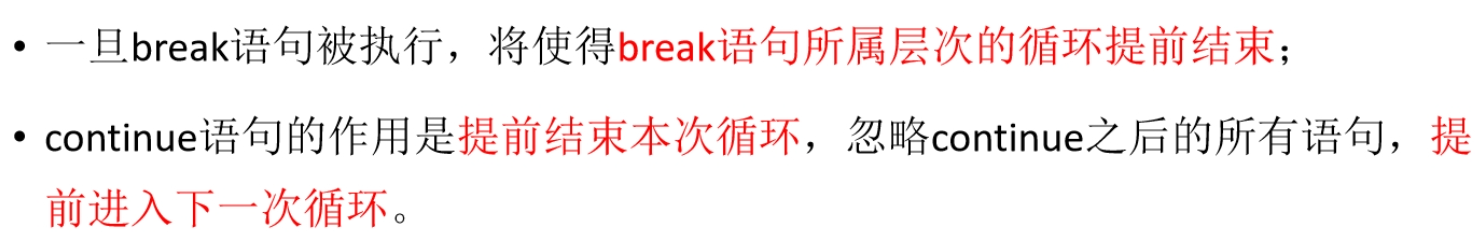

## 第五章： 函数

> 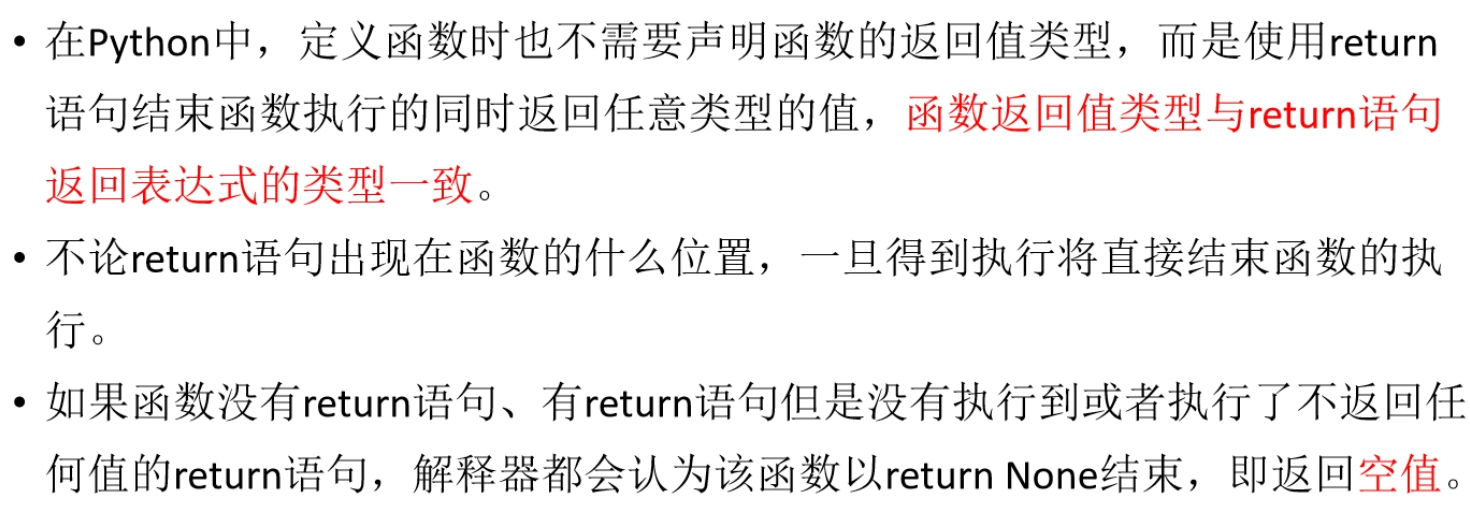

> ## 函数参数：位置参数；默认值参数；关键参数；
> ## 可变长度参数 （* parameter（元组） ** parameter（字典））

> ## 传递参数时候的序列解包
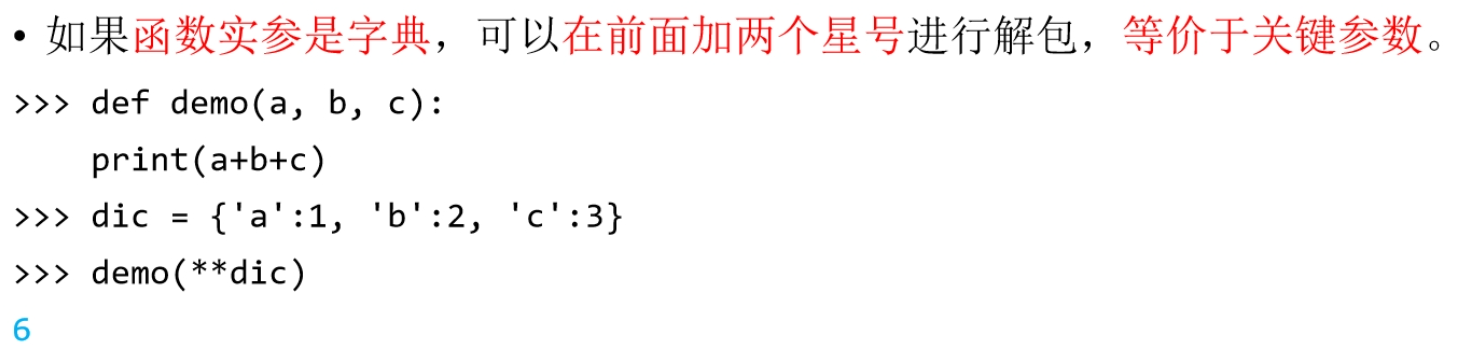



> 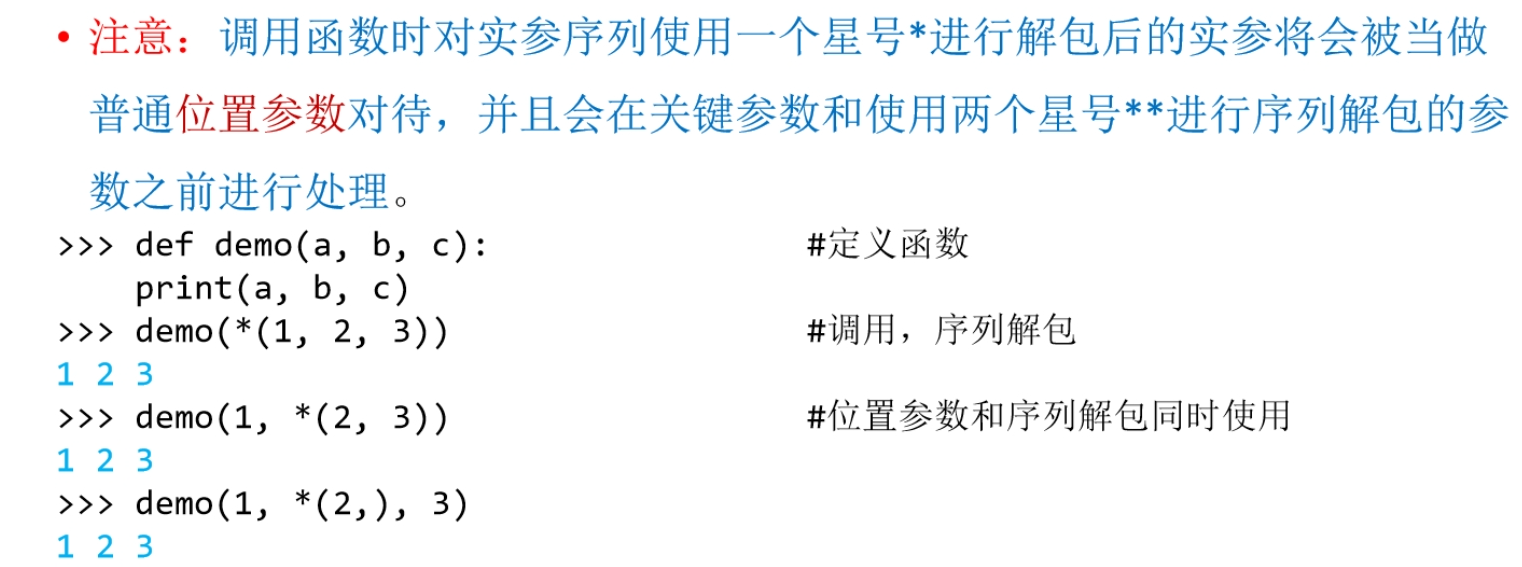

> ## 变量的作用域
> 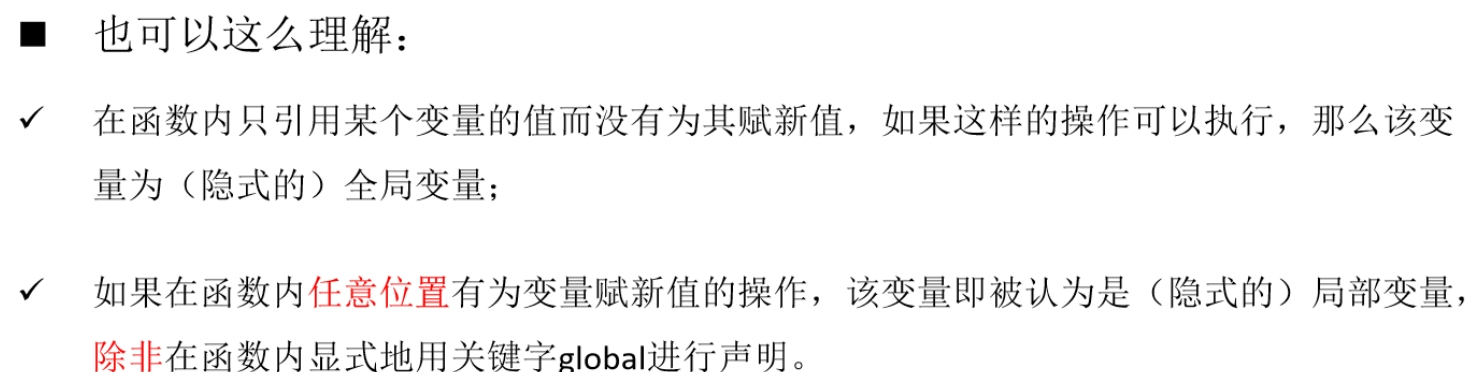

> 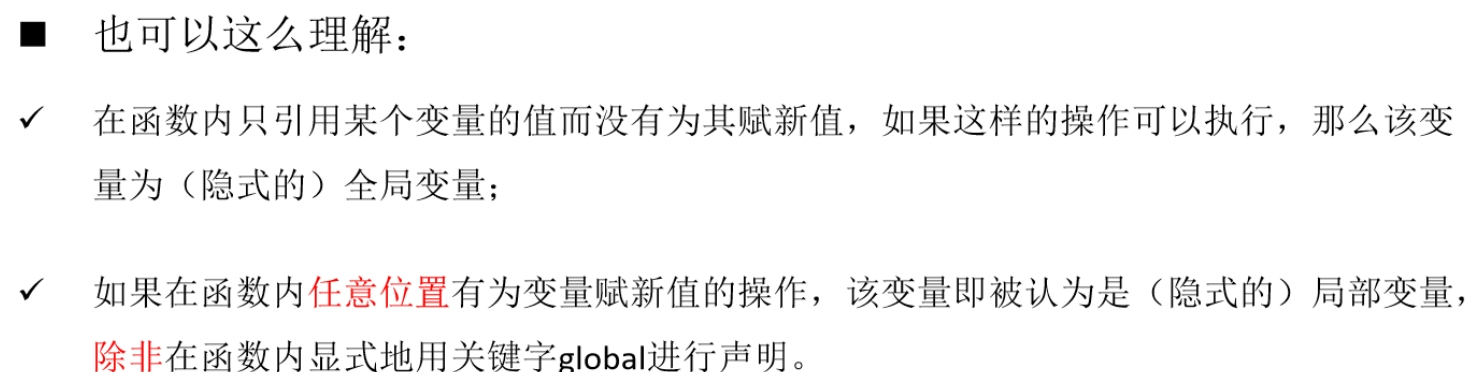


> ## 重点： lambda 表达式 ----- 匿名函数:和map，filter, min, max, sorted等联合使用

> ## 生成器函数： yield

In [133]:
value = 3

def func(para=value):
    print(para) 

value = 5
func(value)

5


In [135]:
value = 3

def func(para=value):
    print(para) 

func()

3


In [51]:
x = ['12', 'Hello', 'apple']
sorted(x, key=lambda y: (len(y)), reverse = True)

['Hello', 'apple', '12']

In [78]:
L = [(lambda x: x**2), (lambda x: x**3), (lambda x: x**4)] 
print(L[0](2),L[1](2),L[2](2), sep=';')

4;8;16


In [52]:
r = []
for x in range(10):
    r.append(lambda n=x:n**2)
r[1](),r[2]()    

(1, 4)

In [46]:
r

[<function __main__.<lambda>(n=0)>,
 <function __main__.<lambda>(n=1)>,
 <function __main__.<lambda>(n=2)>,
 <function __main__.<lambda>(n=3)>,
 <function __main__.<lambda>(n=4)>,
 <function __main__.<lambda>(n=5)>,
 <function __main__.<lambda>(n=6)>,
 <function __main__.<lambda>(n=7)>,
 <function __main__.<lambda>(n=8)>,
 <function __main__.<lambda>(n=9)>]

In [44]:
r = []
for x in range(10):
    r.append(lambda:x**2)
r[1](),r[2]() 

(81, 81)

In [43]:
r

[<function __main__.<lambda>(x)>,
 <function __main__.<lambda>(x)>,
 <function __main__.<lambda>(x)>,
 <function __main__.<lambda>(x)>,
 <function __main__.<lambda>(x)>,
 <function __main__.<lambda>(x)>,
 <function __main__.<lambda>(x)>,
 <function __main__.<lambda>(x)>,
 <function __main__.<lambda>(x)>,
 <function __main__.<lambda>(x)>]

In [136]:
def gen():
    yield from 'ab2'
    
c, d, e = gen()
f= dict(zip(c, e))
print(f)

{'a': '2'}


In [137]:
def gen():
    yield  'ab2'
    
c, d, e = gen()
f= dict(zip(c, e))
print(f)

ValueError: not enough values to unpack (expected 3, got 1)

In [138]:
def outer(x):
    def inner(y=x):
        return y
    return inner

add_five = outer(5)
result = add_five(10)
print(result)

10


In [139]:
def outer(x):
    def inner(y=x):
        return y
    return inner

add_five = outer(5)
result = add_five()
print(result)

5


In [141]:
def double(x):
    return x ** 2

def make_operator(func):
    return lambda y: func(y) + 3

op = make_operator(double)
value = op(4)
print(value)

19


In [144]:
f = lambda x:x**2+3
f(4)

19

## 第六章：类

> ## 数据成员和成员方法（私有成员的访问方法）----- 对象名._类名__xxx

> ## 实例方法，类方法，静态方法（互相的区别和关系，如实例对象是否可以调用类方法，类对象能否可以调用实例方法）

> ## 属性

> ## 继承、多态


In [1]:
class Person(object): #基类必须继承于object，否则在派生类中将无法使用super()函数
    def __init__(self, name = '', age = 20, sex = 'man'):
        self.setName(name)
        self.setAge(age)
        self.setSex(sex)
        
    def setName(self, name):
        if not isinstance(name,str):
            print('name must be string.')
        self.__name = name
        
    def setAge(self, age):
        if not isinstance(age,int):
            print('age must be integer.')
        self.__age = age
        
    def setSex(self, sex):
        if sex != 'man' and sex != 'woman':
            print('sex must be "man" or "woman"')
        self.__sex = sex     
        
    def show(self):
        print(self.__name)
        print(self.__age)
        print(self.__sex)

zhangsan = Person('Zhang San',19,'man')
zhangsan.show()

Zhang San
19
man


In [4]:
class Student(Person):
    def __init__(self, name='', age = 30, sex = 'man', major = 'Computer'):
        #调用基类构造方法初始化基类的私有数据成员
        super(Student, self).__init__(name, age, sex)
        self.setMajor(major) #初始化派生类的数据成员
    def setMajor(self, major):
        if not isinstance(major, str):
            print('major must be a string.')
            #return
        self.__major = major
    def show(self):
        super(Student,self).show()
        print(self.__major)

if __name__ =='__main__':
    zhangsan = Person('Zhang San',19, 'man')
    zhangsan.show()
    lisi = Student('Li Si',32, 'man', 'Math')
    lisi.show()


Zhang San
19
man
Li Si
32
man
Math


In [27]:
print = 3
print

3

In [42]:
isinstance(3,int)

True

In [61]:
import types
class Person(object):
    def __init__(self, name):
        assert isinstance(name, str), 'name must be string'
        self.name = name
    def walk(self):
        return (self.name+' can walk.')  
        
def sing(self):
    print(self.name+' can sing.')
    
    
# 类对象调用实例方法,显示地传入self参数
zhang = Person('zhang')
Person.walk(zhang)

'zhang can walk.'

In [62]:
zhang.sing = types.MethodType(sing, zhang) #动态增加一个新行为
zhang.sing()

zhang can sing.


In [63]:
#sing方法是独属于实例对象zhang的方法，不属于类对象的方法，因此类对象没有访问权限
Person.sing(zhang)

AttributeError: type object 'Person' has no attribute 'sing'

In [64]:
# 将sing方法添加到类对象下面的实例方法（动态给类添加方法（影响所有实例））
Person.sing = sing
Person.sing(zhang)

zhang can sing.


## 第七，八章：字符串和正则化表达式

>## GBK(3字节/中文）,CP936(2字节/中文）: seek()

>## 转义字符：\n 

>## 字符串格式化方法：%, format， f

>## 字符串常用操作：split, partition, join, lower, upper, swapcase, replace, strip，index, find

>## 字符串的内置函数：len， max, eval

>## 字符串支持切片操作，但是不可以修改（可哈希的）

In [1]:
position = [(5, 8, 13),('a','b','c')]
print("X:{0[0][0]};Y:{0[1][2]};Z:{0[1][2]}".format(position))

X:5;Y:c;Z:c


In [3]:
name = 'Dong'
age = 39
f'My name is {name}, and I am {age} years old.'

'My name is Dong, and I am 39 years old.'

In [1]:
'Beautiful is better than ugly.'.index('beautiful')

ValueError: substring not found

In [3]:
'Beautiful is better than ugly.'.find('beautiful')

-1

In [2]:
'Beautiful is better than ugly.'.index('Beautiful')

0

——————————————————————————————————————————————————————————————————————

>## 正则表达式语法和集锦（表8-1，8.1.3节）

>## re模块：findall：列表形式返回；fullmatch，match，search：返回match对象或者None    split，sub


In [68]:
import re

def main(lst, pattern):
    return [(s,c) for s,c in enumerate(lst) if re.findall(pattern, c)]

data = ["apple", "banana", "cherry"]
pattern = r'\ba.*'
result = main(data, pattern)
print(result) 

[(0, 'apple')]


In [19]:
s=re.sub('[a-c]', lambda x:x.group(0).upper(), 'aaa abc abde')
print(s)

AAA ABC ABde


In [72]:
import re

def main(lst, pattern):
    return [(i, s) for i, s in enumerate(lst) if re.findall(pattern, s)]

# 测试代码
data = ["apple", "banana", "cherry"]
pattern = r'a.'
result = main(data, pattern)
print(result)

[(0, 'apple'), (1, 'banana')]


In [76]:
data = ["apple", "banana", "cherry"]
re.findall(r'a.', data[1])

['an', 'an']

In [40]:
words = ['apple', 'banana', 'avocado', 'grape']
gen = [word for word in words if re.findall(r'\Ba', word)]
print(gen)

['banana', 'avocado', 'grape']


In [16]:
import re
x = 'If the implementatIon is hard to explain, it is a bad idea.'
x = re.sub(r'\BI\B', r'i', x)
print(x)


If the implementation is hard to explain, it is a bad idea.


In [17]:
text = "If the implementatIon is hard to explain, it's a bad idea."
result = ''

for index, ch in enumerate(text):
     if ch=='I' and text[index-1].isalpha() and text[index+1].isalpha():
          ch = 'i'
     result += ch

print(result)


If the implementation is hard to explain, it's a bad idea.


In [5]:
import re

x = 'This is is a desk.'
x = re.sub(r'(\w+ )\1', r'\1', x)
print(x)


This is a desk.


In [6]:
text = '111a22bb3ccc'
re.findall('(\d+?)[a-z]', text)

['111', '22', '3']

## 第九、十章：文件内容和文件夹内容操作

>## open() 表9-1(以不同方式打开文件时候，指针位置不同，(w+ 会清空文件,r+不会清空文件)), with open...

>## 文件对象常用方法：close(), read(), readline()：返回字符串, readlines():返回列表，seek， write():字符串, writelines：字符串列表写入

>## 文本文件： json

 > ## 二进制文件： pickle、struct、shelve(了解）



——————————————————————————————————————————————————————————
>## os模块：remove, rename, replace, listdir


>## os.path模块： basename，commonpath，split，splitext，join

## 第十一章：异常处理结构和单元测试

>## 异常处理结构层次：ZeroDivisionError, TypeError， IndentationError...


>## 异常处理结构：try...except...; try... except... else...; try... except... finally(可能会引发异常）... 可捕捉多种异常处理结构




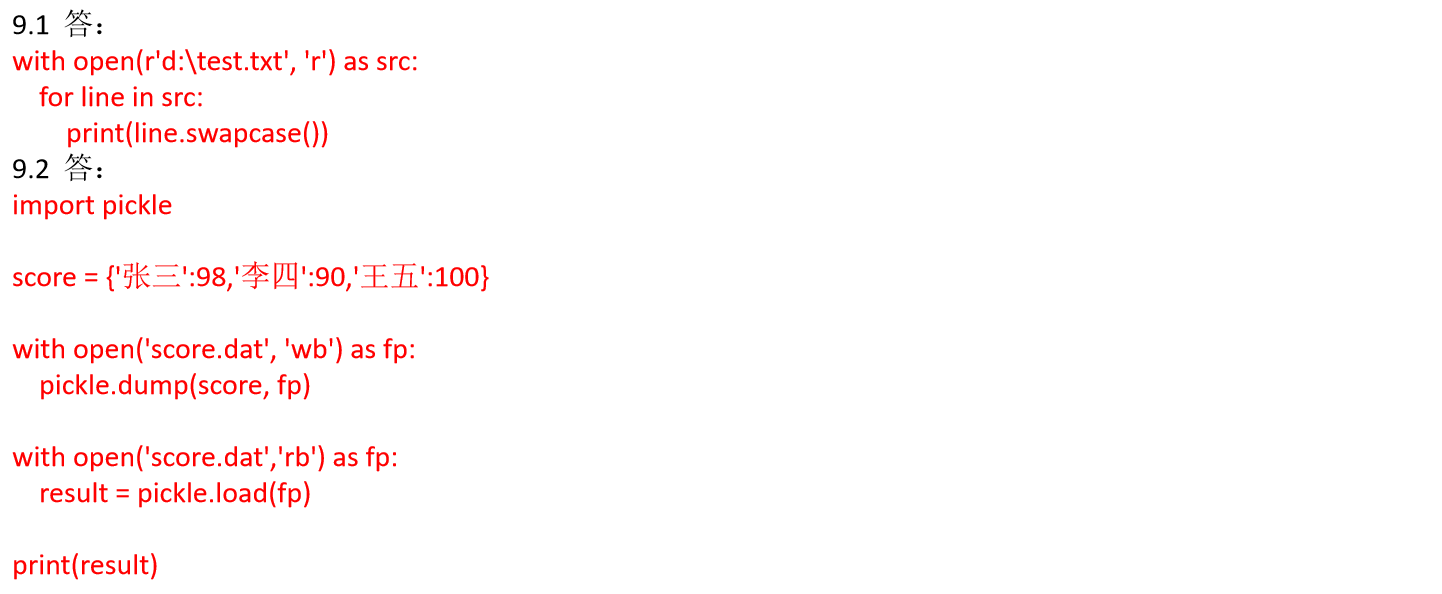

In [107]:
x = 'better\n  life'
with open('temp.txt', 'w') as fp:
    fp.write(x)

In [108]:
with open('temp.txt', 'r') as fp:
    print(fp.readlines())

['better\n', '  life']


In [113]:
with open('temp.txt', 'r') as fp:
    print(fp.readline())

better



In [114]:
type(_)

type

In [110]:
with open('temp.txt', 'r') as fp:
    for line in fp:
        print(line.strip())

better
life


In [115]:
with open('sample1.txt', 'w+',encoding='utf8') as fp:
    fp.write('文件阅读文件编辑方法')
    fp.seek(12)
    fp.write('测试')
    fp.seek(0)
    print(fp.read())

文件阅读测试编辑方法


In [116]:
from os.path import splitext
splitext(r'C:\Python39\python.exe')

('C:\\Python39\\python', '.exe')

In [145]:
def demo(a, n):
    assert type(n)==int and type(a)==int and 0<a<10, 'n must be int; a must be integer between 1 and 9'
    result, t = 0, 0
    for i in range(n):
        t = t*10 + a
        result += t
    return result

print(demo(3, 4))

3702
